### 1. Introduction

Phishing websites are a major problem in online platforms, especially in e-banking and e-commerce, where users can be tricked into sharing sensitive information. Detecting such websites automatically is an important task.

In this project, a **Feedforward Neural Network (FNN)** is used to classify websites into three categories: **phishing, legitimate, and suspicious**. The dataset contains 1353 websites collected from different sources, including Phishtank and Yahoo directories. The suspicious class represents websites that show both phishing and legitimate characteristics.

The dataset already includes numerical features. Feature scaling is applied before training the model. Different hyperparameters such as **optimizers, number of neurons, and dropout** rates are tested to improve performance.

The model is evaluated using **accuracy, precision, recall, and F1-score**, along with visualizations like **loss curves** and **confusion matrix** to better understand the results.

In [2]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


#### Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from ucimlrepo import fetch_ucirepo

# Preprocessing
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

2026-03-17 22:05:34.202227: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 2. Dataset Description

The dataset used in this project is the **Website Phishing** dataset obtained from the **UCI Machine Learning Repository (ID: 379)**. 
This dataset contains information about different websites and their characteristics, So, the goal is to classifying each website as phishing, legitimate, or suspicious.

The dataset includes a total of 1353 websites collected from various sources. Phishing websites were taken from the Phishtank archive, while legitimate websites were collected from Yahoo directories. Among these, **702 are phishing**, **548 are legitimate**, and **103 are labeled as suspicious**.

The suspicious category represents websites that show both phishing and legitimate features, making them more challenging to classify.

The dataset consists of multiple numerical features describing the properties of each website. These features are directly used as input to the neural network after applying feature scaling.

#### Load Dataset

In [2]:
website_phishing = fetch_ucirepo(id=379)

X = website_phishing.data.features
y = website_phishing.data.targets

print(X.shape)
print(y.shape)

X.head()

(1353, 9)
(1353, 1)


,SFH,popUpWindow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address
0,1,-1,1,-1,-1,1,1,1,0
1,-1,-1,-1,-1,-1,0,1,1,1
2,1,-1,0,0,-1,0,-1,1,0
3,1,0,1,-1,-1,0,1,1,0
4,-1,-1,1,-1,0,0,-1,1,0


### Dataset Metadata

In [3]:
print(website_phishing.metadata)
print(website_phishing.variables)

{'uci_id': 379, 'name': 'Website Phishing', 'repository_url': 'https://archive.ics.uci.edu/dataset/379/website+phishing', 'data_url': 'https://archive.ics.uci.edu/static/public/379/data.csv', 'abstract': '\n\n', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1353, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Result'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2014, 'last_updated': 'Thu Mar 21 2024', 'dataset_doi': '10.24432/C5B301', 'creators': ['Neda Abdelhamid'], 'intro_paper': {'ID': 440, 'type': 'NATIVE', 'title': 'Phishing detection based Associative Classification data mining', 'authors': 'Neda Abdelhamid, A. Ayesh, F. Thabtah', 'venue': 'Expert systems with applications', 'year': 2014, 'journal': None, 'DOI': '10.1016/j.eswa.2014.03.019', 'URL': 'https://www.semanticscholar.org/paper/867e2293e9780b729705b4ba48d6b1

### Data Preprocessing
In the data preprocessing I used the following steps before training the neural network.

- The original labels (-1, 0, 1) are encoded into (0, 1, 2) using **LabelEncoder**, so that they can be used with the multiclass classification model.

- Feature scaling is applied using **standardization**. This ensures that all input features are on a similar scale, which helps the neural network train more effectively.

- The dataset is divided into training and testing sets using a **70:30** split. The training set is used to train the model, while the testing set is used to evaluate its performance on unseen data.


In [4]:
print(X.info())

print("\nMissing values:")
print(X.isnull().sum())

print("\nTarget distribution:")
print(pd.Series(y.values.ravel()).value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   SFH                1353 non-null   int64
 1   popUpWindow        1353 non-null   int64
 2   SSLfinal_State     1353 non-null   int64
 3   Request_URL        1353 non-null   int64
 4   URL_of_Anchor      1353 non-null   int64
 5   web_traffic        1353 non-null   int64
 6   URL_Length         1353 non-null   int64
 7   age_of_domain      1353 non-null   int64
 8   having_IP_Address  1353 non-null   int64
dtypes: int64(9)
memory usage: 95.3 KB
None

Missing values:
SFH                  0
popUpWindow          0
SSLfinal_State       0
Request_URL          0
URL_of_Anchor        0
web_traffic          0
URL_Length           0
age_of_domain        0
having_IP_Address    0
dtype: int64

Target distribution:
-1    702
 1    548
 0    103
Name: count, dtype: int64


In [5]:
X.describe()

,SFH,popUpWindow,SSLfinal_State,Request_URL,URL_of_Anchor,web_traffic,URL_Length,age_of_domain,having_IP_Address
count,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000,1353.000000
mean,0.237990,-0.258684,0.327421,-0.223208,-0.025129,0.000000,-0.053215,0.219512,0.114560
std,0.916389,0.679072,0.822193,0.799682,0.936262,0.806776,0.762552,0.975970,0.318608
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
25%,-1.000000,-1.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.000000
50%,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Class Distribution Visualization

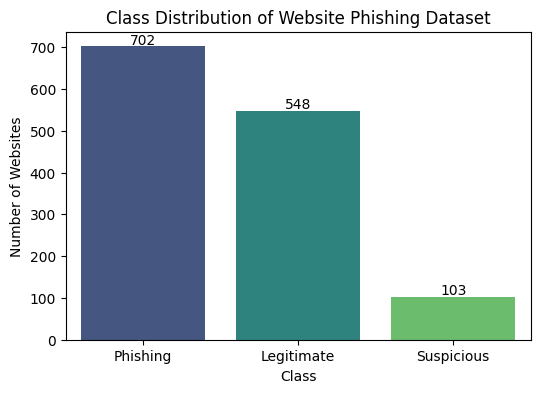

In [6]:
y = np.array(y).ravel()

# Map numeric labels to names
class_names = {
    -1: "Phishing",
     0: "Suspicious",
     1: "Legitimate"
}

# Convert to pandas series and map labels
y_named = pd.Series(y).map(class_names)

# Count classes
class_counts = y_named.value_counts().reset_index()
class_counts.columns = ["class", "count"]

# Plot
plt.figure(figsize=(6,4))

sns.barplot(
    data=class_counts,
    x="class",
    y="count",
    hue="class",
    palette="viridis",
    legend=False
)

plt.title("Class Distribution of Website Phishing Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Websites")

# Add labels above bars
for i, v in enumerate(class_counts["count"]):
    plt.text(i, v + 5, str(v), ha='center')

plt.show()

#### Feature Scaling

In [7]:
# Convert target to 1D array
y = np.array(y).ravel()

# Encode labels (-1,0,1 → 0,1,2)
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y = encoder.fit_transform(y)

print("Encoded classes:", np.unique(y))

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Encoded classes: [0 1 2]


### Train - Test Split

In [8]:
# Train-Test Split (70 : 30)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y,test_size=0.30,random_state=42)

### Model Architecture
In this project a **feedforward neural network** is designed to categorize websites into three groups phishing legitimate and suspicious the model uses numerical attributes extracted from each website as its input the architecture is built using a sequence of fully connected layers.

The model consists of multiple dense layers with **relu activation** which helps in learning patterns from the data **dropout** layers are added to reduce overfitting.

The output layer contains three units corresponding to the target classes a **softmax** function is used at this stage to convert the outputs into class probabilities enabling the model to make a final prediction.

The model is trained using **sparse categorical cross-entropy** loss. Different **optimisers** are evaluated during experimentation to determine which one leads to better convergence and overall performance.

#### Build Feedforward Neural Network

In [9]:
def build_model(optimizer='adam', neurons=32, dropout_rate=0.3):

    model = Sequential()

    model.add(Dense(neurons, activation='relu', input_shape=(X_train.shape[1],)))
    model.add(Dropout(dropout_rate))

    model.add(Dense(neurons//2, activation='relu'))

    model.add(Dense(3, activation='softmax'))

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Training the Neural Network
After defining the model, the neural network is trained using the training dataset. The model learns patterns from the input features and updates its weights using the selected optimizer.

The model is trained for multiple epochs with a fixed batch size. A validation split is used to check the model’s performance during training and to see if it is overfitting.

The training process provides a history of accuracy and loss values, which can be used to understand how well the model is learning.

In [10]:
model = build_model()

history = model.fit(X_train,y_train, epochs=50,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/50


/home/rajat/nlp_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 22:06:15.738893: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.3514 - loss: 1.1592 - val_accuracy: 0.6895 - val_loss: 0.9259
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6460 - loss: 0.8844 - val_accuracy: 0.7579 - val_loss: 0.7558
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7411 - loss: 0.7207 - val_accuracy: 0.7895 - val_loss: 0.6470
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7701 - loss: 0.6335 - val_accuracy: 0.7947 - val_loss: 0.5763
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7886 - loss: 0.5732 - val_accuracy: 0.8000 - val_loss: 0.5362
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7952 - loss: 0.5433 - val_accuracy: 0.8158 - val_loss: 0.5135
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8124 - loss: 0.5188 - val_accuracy: 0.8316 - val_loss: 0.4991
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8203 - loss: 0.4885 - val_accuracy: 0.8316 - val_loss: 0.4928
Ep

### Training vs Validation Loss Curve

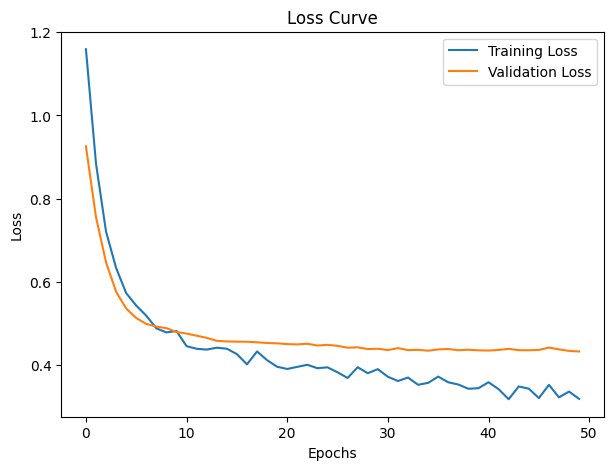

In [11]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8448 - loss: 0.4123 
Test Loss: 0.41231751441955566
Test Accuracy: 0.8448275923728943


### Model Evaluation

In [13]:
y_pred = np.argmax(model.predict(X_test), axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred, average='weighted'))

print("Recall:", recall_score(y_test, y_pred, average='weighted'))

print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy: 0.8448275862068966
Precision: 0.8274249230537604
Recall: 0.8448275862068966
F1 Score: 0.8244002013491901

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.92      0.90       203
           1       0.56      0.14      0.23        35
           2       0.81      0.90      0.85       168

    accuracy                           0.84       406
   macro avg       0.75      0.65      0.66       406
weighted avg       0.83      0.84      0.82       406



### Confusion Matrix

Text(0.5, 1.0, 'Confusion Matrix')

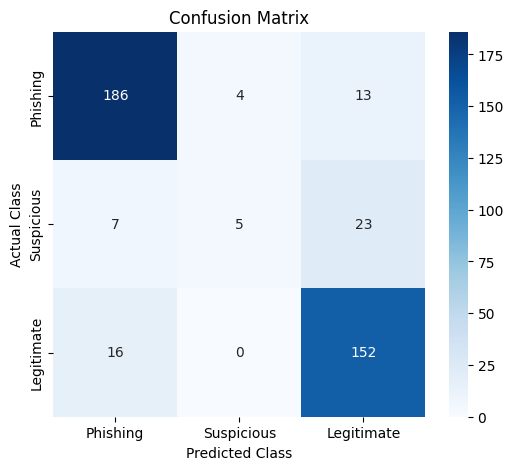

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing","Suspicious","Legitimate"],
    yticklabels=["Phishing","Suspicious","Legitimate"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

### Hyperparameter Tuning

Hyperparameter tuning is performed to improve the performance of the neural network. Different configurations are tested to find the best combination.

First, different optimizers such as **Adam, SGD and RMSprop** are compared. Then, the number of **neurons and dropout** rates are varied to study their impact on accuracy.

**Cross-validation** is also applied to check the stability and consistency of the model across different data splits.

#### Optimizer tuning

In [15]:
optimizers = ['adam','sgd','rmsprop']

optimizer_results = {}

for opt in optimizers:

    model = build_model(optimizer=opt)

    model.fit(
        X_train,
        y_train,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    optimizer_results[opt] = acc

print(optimizer_results)

/home/rajat/nlp_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


{'adam': 0.8374384045600891, 'sgd': 0.8325123190879822, 'rmsprop': 0.8448275923728943}


### Hyperparameter Comparison Plots

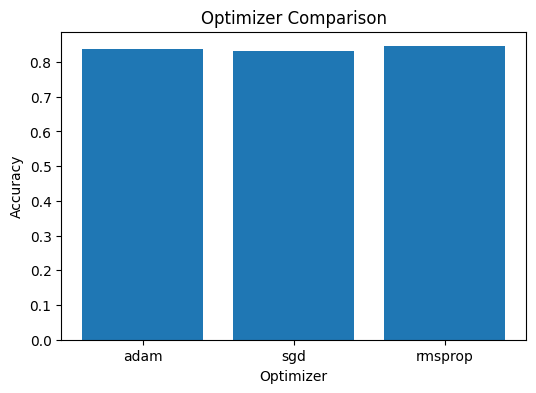

In [16]:
plt.figure(figsize=(6,4))

plt.bar(
    optimizer_results.keys(),
    optimizer_results.values()
)

plt.ylabel("Accuracy")
plt.xlabel("Optimizer")
plt.title("Optimizer Comparison")

plt.show()

#### Neuron + Dropout tuning

In [17]:
neurons_list = [16,32,64,128]
dropouts = [0.2,0.3,0.4,0.5]

results = []

for n in neurons_list:
    for d in dropouts:

        model = build_model(neurons=n, dropout_rate=d)

        model.fit(
            X_train,
            y_train,
            epochs=30,
            batch_size=32,
            verbose=0
        )

        loss, acc = model.evaluate(X_test, y_test, verbose=0)

        results.append((n,d,acc))

results

[(16, 0.2, 0.8275862336158752),
 (16, 0.3, 0.8275862336158752),
 (16, 0.4, 0.825123131275177),
 (16, 0.5, 0.8275862336158752),
 (32, 0.2, 0.8275862336158752),
 (32, 0.3, 0.8448275923728943),
 (32, 0.4, 0.8423645496368408),
 (32, 0.5, 0.8423645496368408),
 (64, 0.2, 0.8546798229217529),
 (64, 0.3, 0.8497536778450012),
 (64, 0.4, 0.8472906351089478),
 (64, 0.5, 0.8448275923728943),
 (128, 0.2, 0.8916256427764893),
 (128, 0.3, 0.866995096206665),
 (128, 0.4, 0.8645319938659668),
 (128, 0.5, 0.8620689511299133)]

#### Cross Validation
The cross-validation results show that the model achieves consistent performance across different data splits, indicating good generalization ability. The low variation in accuracy suggests that the model is stable and not overly dependent on a specific training set.

In [18]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

for train_idx, test_idx in kfold.split(X_scaled):

    model = build_model()

    model.fit(
        X_scaled[train_idx],
        y[train_idx],
        epochs=30,
        batch_size=32,
        verbose=0
    )

    loss, acc = model.evaluate(X_scaled[test_idx], y[test_idx], verbose=0)

    cv_scores.append(acc)

print("Cross Validation Accuracy:", np.mean(cv_scores))

Cross Validation Accuracy: 0.8551455616950989


### Overfitting Analysis (Learning Curves)
To analyze the model’s learning behavior, training and validation curves are plotted. These curves show how accuracy and loss change over epochs.

By comparing training and validation performance, it is possible to observe whether the model is overfitting or learning effectively.

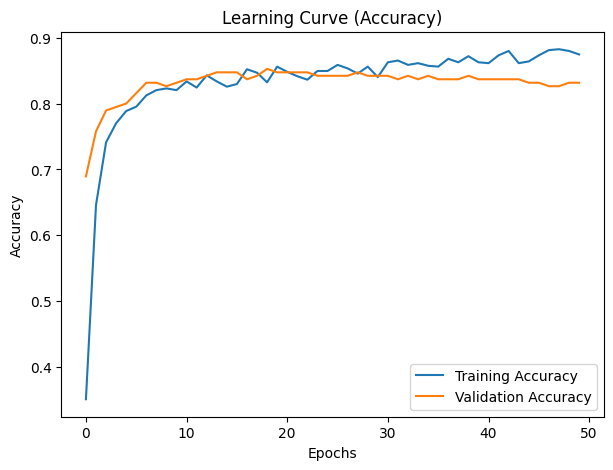

In [19]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Accuracy)")
plt.legend()

plt.show()

### Best Hyperparameters

#### Best optimizer

In [20]:
optimizer_df = pd.DataFrame(
    list(optimizer_results.items()),
    columns=["Optimizer", "Accuracy"]
)

optimizer_df
best_optimizer = optimizer_df.loc[optimizer_df["Accuracy"].idxmax()]

print("Best Optimizer:")
print(best_optimizer)

Best Optimizer:
Optimizer     rmsprop
Accuracy     0.844828
Name: 2, dtype: object


#### Best Neuron + Dropout

In [21]:
nd_df = pd.DataFrame(
    results,
    columns=["Neurons","Dropout Rate","Accuracy"]
)
# nd_df
# neuron_results = nd_df.groupby("Neurons")["Accuracy"].mean()

# neuron_results

best_nd = nd_df.loc[nd_df["Accuracy"].idxmax()]

print("Best Neuron + Dropout:")
print(best_nd)

Best Neuron + Dropout:
Neurons         128.000000
Dropout Rate      0.200000
Accuracy          0.891626
Name: 12, dtype: float64


### Performance Evaluation
A final model is built using the best hyperparameters obtained from tuning. The model uses RMSprop optimizer with 128 neurons and a dropout rate of 0.2.

This model is trained again on the training dataset to achieve improved performance.

In [22]:
final_model = build_model(
    optimizer='rmsprop',
    neurons=128,
    dropout_rate=0.2
)

history_final = final_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

/home/rajat/nlp_env/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7596 - loss: 0.7091 - val_accuracy: 0.8316 - val_loss: 0.5553
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8322 - loss: 0.4929 - val_accuracy: 0.8316 - val_loss: 0.4893
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8283 - loss: 0.4415 - val_accuracy: 0.8158 - val_loss: 0.4712
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8454 - loss: 0.4194 - val_accuracy: 0.8316 - val_loss: 0.4615
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8468 - loss: 0.3941 - val_accuracy: 0.8316 - val_loss: 0.4578
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8520 - loss: 0.3768 - val_accuracy: 0.8316 - val_loss: 0.4542
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8494 - loss: 0.3722 - val_accuracy: 0.8263 - val_loss: 0.4486
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8679 - loss: 0.3426 - val_accuracy: 0.8316 - val_loss

### Prediction with Final Model

In [23]:
y_pred_final = np.argmax(final_model.predict(X_test), axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


### Evaluation
The final model is evaluated using the test dataset. Performance is measured using accuracy, precision, recall, and F1-score.

The results show that the tuned model performs better compared to the initial model.

In [24]:
print("Final Model Accuracy:", accuracy_score(y_test, y_pred_final))

Final Model Accuracy: 0.8866995073891626


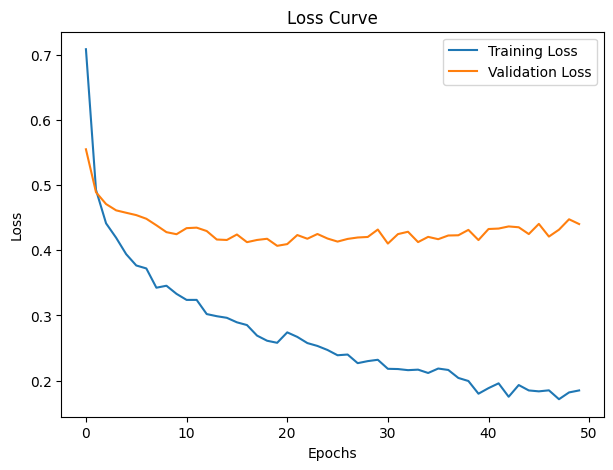

In [25]:
plt.figure(figsize=(7,5))

plt.plot(history_final.history['loss'], label="Training Loss")
plt.plot(history_final.history['val_loss'], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()

### Confusion Matrix
A confusion matrix is used to analyze the model’s predictions in detail. It shows how many samples are correctly and incorrectly classified for each class.

From the confusion matrix, it can be observed that the model performs well for phishing and legitimate classes, while the suspicious class is more challenging due to fewer samples.

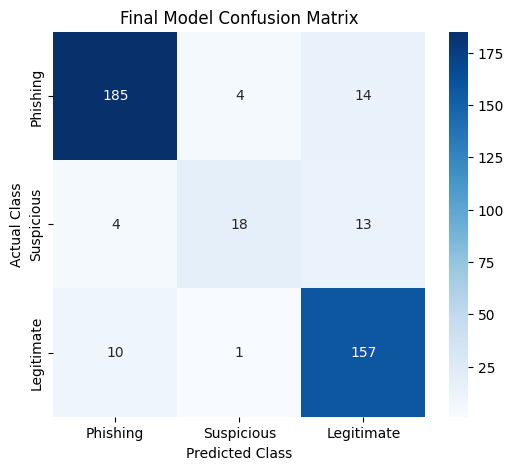

In [26]:
cm_final = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Phishing","Suspicious","Legitimate"],
    yticklabels=["Phishing","Suspicious","Legitimate"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Final Model Confusion Matrix")

plt.show()

### Conclusion 

In this project a neural network was used to classify websites into phishing legitimate and suspicious categories.

The model was improved step by step by trying different optimizers and adjusting parameters like the number of neurons and dropout which helped in achieving better performance.

The results show that the model can clearly identify phishing and legitimate websites but it finds the suspicious category more difficult since it shares features with both classes this makes those cases harder to classify accurately overall this work shows that with proper tuning and evaluation neural networks can be quite effective for website classification tasks while also highlighting the challenges involved in handling uncertain or mixed cases.